<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# DBSCAN - Density-Based Spatial Clustering of Applications with Noise


O DBSCAN é um algoritmo de agrupamento baseado em **densidade**.

A ideia principal é:

> pontos próximos entre si, em regiões densas, pertencem ao mesmo grupo.

O DBSCAN consegue identificar:

- grupos com formatos arbitrários;
- ruídos;
- outliers;
- regiões de baixa densidade.


## Processo de Clusterização com o DBSCAN

O DBSCAN classifica os pontos em três categorias principais.

## Ponto central

Um ponto é considerado **central** quando existem pelo menos `min_samples` pontos dentro de uma distância `eps`.

## Ponto de borda

Um ponto de borda não possui vizinhos suficientes para ser central, mas está dentro da vizinhança de um ponto central.

## Ruído

Um ponto é considerado **ruído** quando não é ponto central nem ponto de borda.

No `scikit-learn`, os pontos classificados como ruído recebem o rótulo $-1$.


## Cálculo da Distância

A distância é calculada pela seguinte equação:

$$
d(p, q) = \sqrt{\sum_{j=1}^{m}(p_i - q_j)^2}
$$

## Principais Parâmetros do DBSCAN

## 5.1 `eps`

Define o raio da vizinhança.

Em outras palavras:

$$
\epsilon = \text{distância máxima para dois pontos serem considerados vizinhos}
$$

Se `eps` for muito pequeno, muitos pontos podem virar ruído.

Se `eps` for muito grande, grupos diferentes podem ser unidos indevidamente.

## `min_samples`

Define o número mínimo de pontos necessários dentro da vizinhança para formar uma região densa.

Inclui o próprio ponto analisado.


# Exemplo em Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

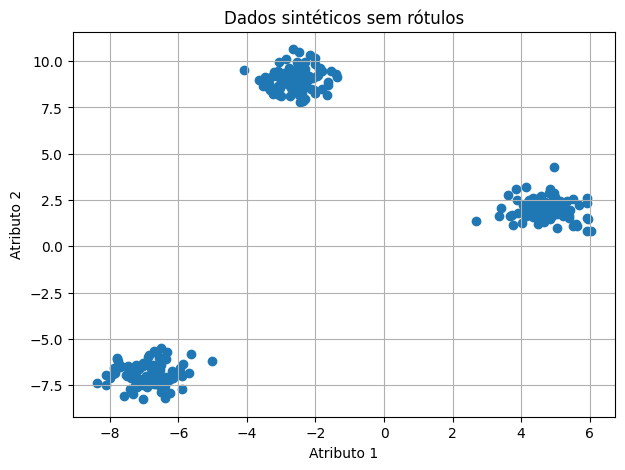

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dados sintéticos sem rótulos")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.grid(True)
plt.show()

In [3]:
dbscan = DBSCAN(eps=0.7, min_samples=5)

labels = dbscan.fit_predict(X)

print("Rótulos encontrados:")
print(np.unique(labels))

Rótulos encontrados:
[-1  0  1  2]


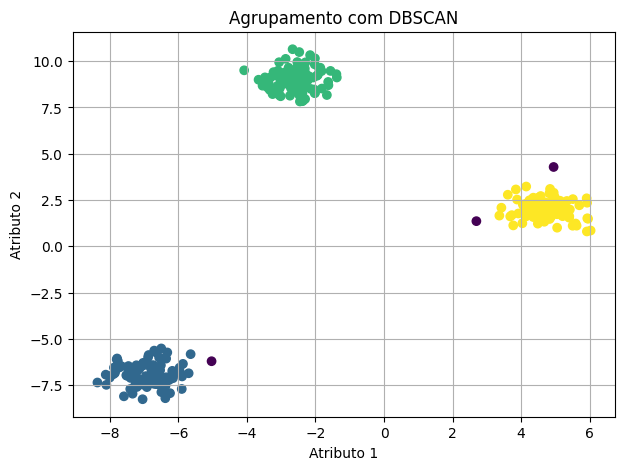

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
plt.title("Agrupamento com DBSCAN")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.grid(True)
plt.show()

# DBSCAN com Dados em Formato em Meia-Lua

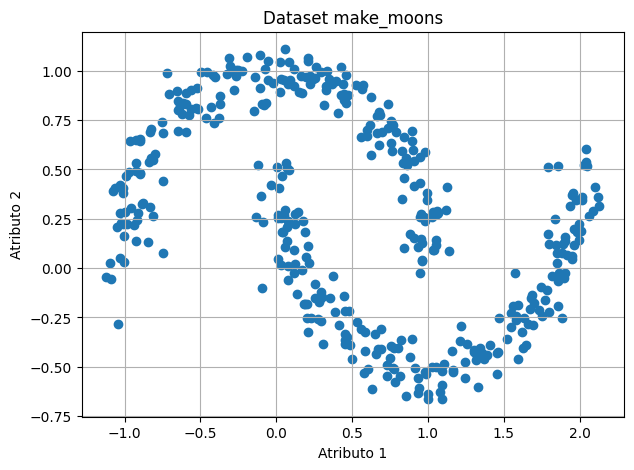

In [5]:
X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.08,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1])
plt.title("Dataset make_moons")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.grid(True)
plt.show()

# K-Means versus DBSCAN

O K-Means tenta formar grupos aproximadamente circulares.

O DBSCAN procura regiões densas, o que permite encontrar grupos com formatos mais complexos.

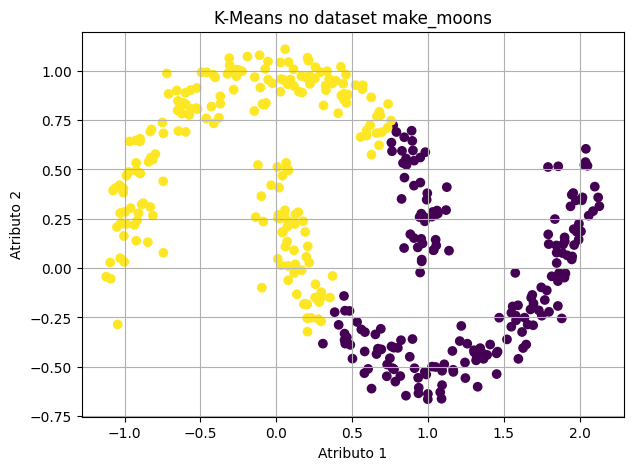

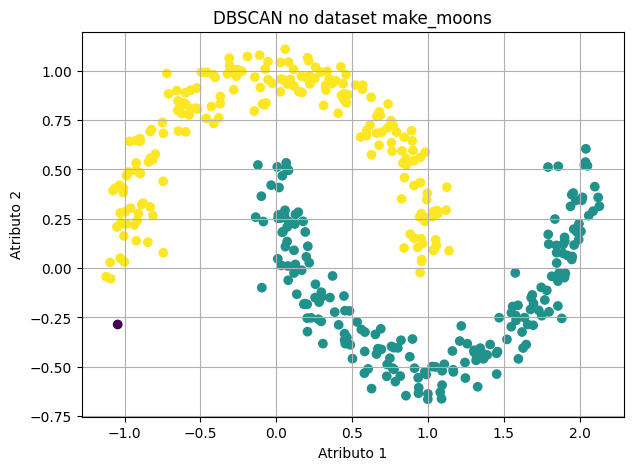

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_moons)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moons)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans, cmap="viridis")
plt.title("K-Means no dataset make_moons")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan, cmap="viridis")
plt.title("DBSCAN no dataset make_moons")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.grid(True)
plt.show()

# 14. Como escolher o parâmetro `eps`?

Uma forma prática é usar o gráfico da distância até o k-ésimo vizinho mais próximo.

Normalmente é utilizado:

$$
k = \text{min_samples}
$$

Depois procuramos um ponto de "cotovelo" no gráfico.

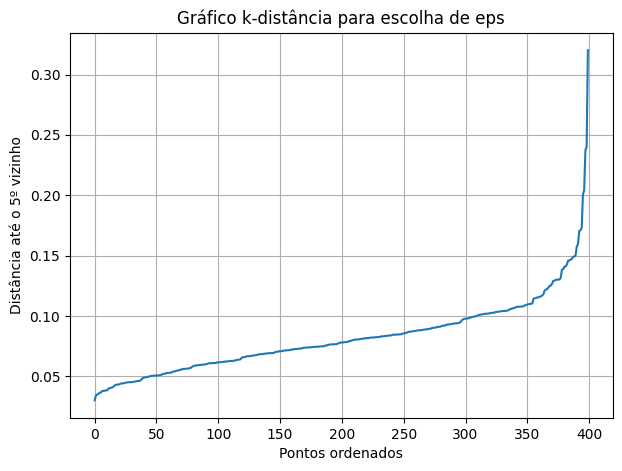

In [7]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_moons)

distances, indices = neighbors_fit.kneighbors(X_moons)

# Distância até o k-ésimo vizinho
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances)
plt.title("Gráfico k-distância para escolha de eps")
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância até o {min_samples}º vizinho")
plt.grid(True)
plt.show()

# Diferentes Valores de `eps`


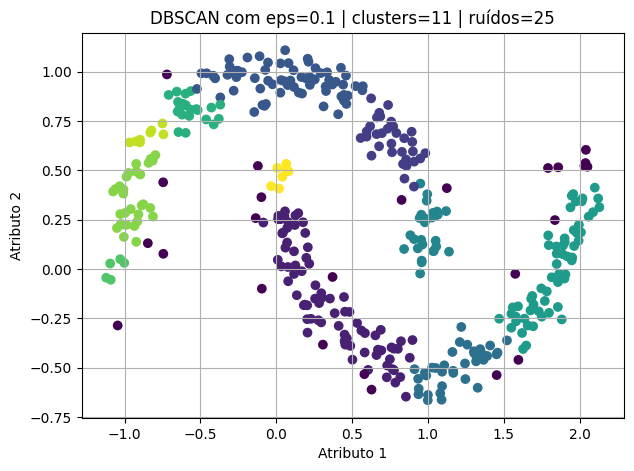

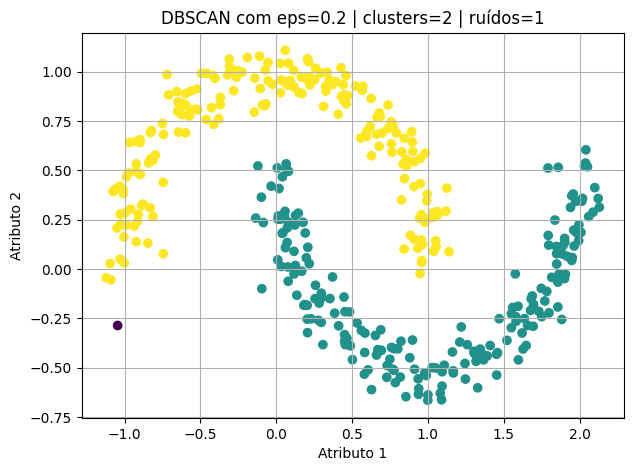

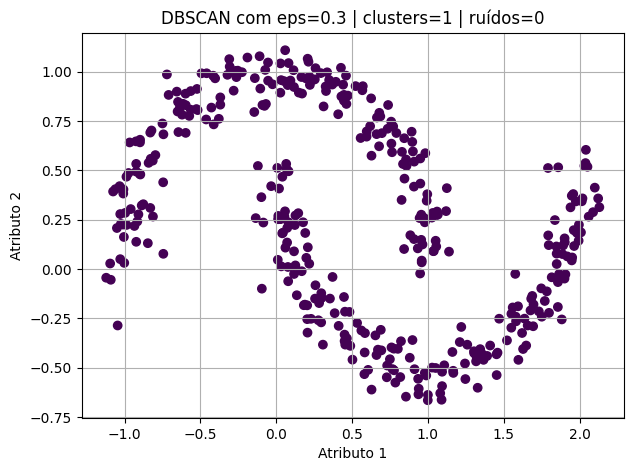

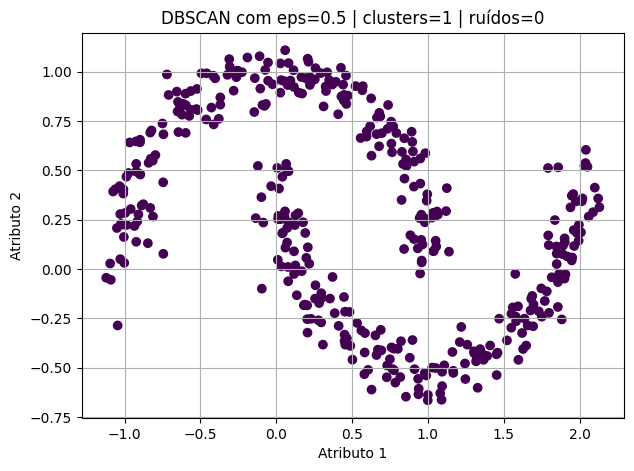

In [ ]:
valores_eps = [0.1, 0.2, 0.3, 0.5]

for eps in valores_eps:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_moons)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruidos = list(labels).count(-1)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="viridis")
    plt.title(f"DBSCAN com eps={eps} | clusters={n_clusters} | ruídos={n_ruidos}")
    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.grid(True)
    plt.show()

# Diferentes Valores de `min_samples`



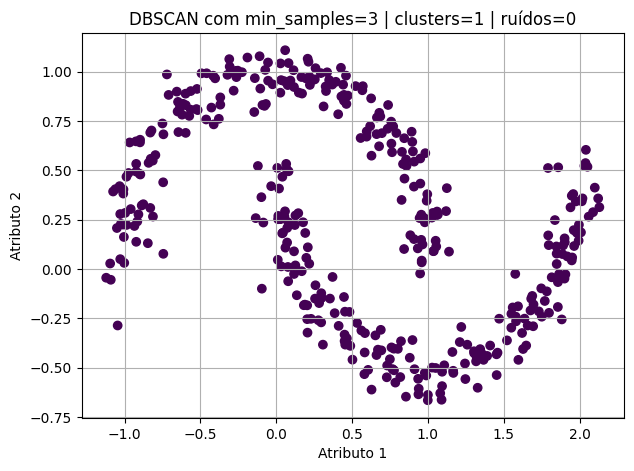

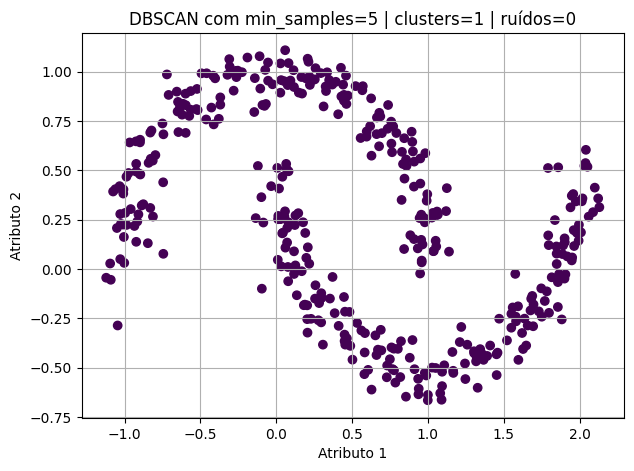

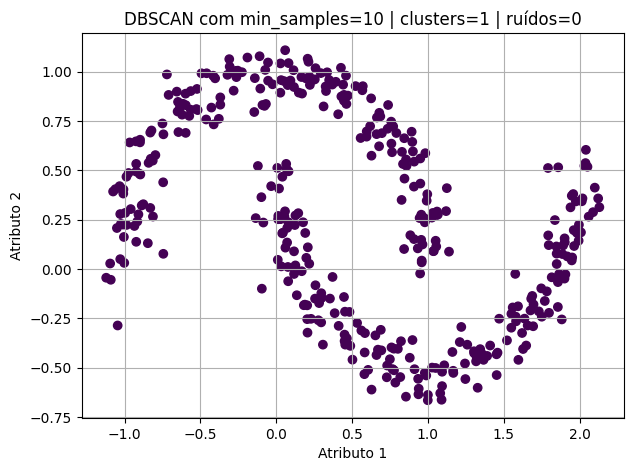

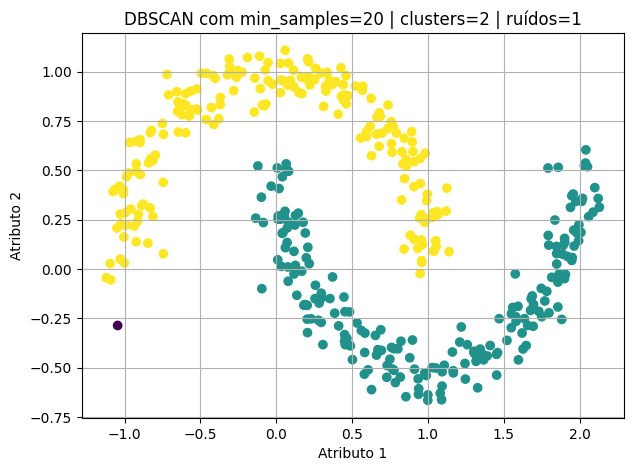

In [ ]:
valores_min_samples = [3, 5, 10, 20]

for min_samples in valores_min_samples:
    dbscan = DBSCAN(eps=0.3, min_samples=min_samples)
    labels = dbscan.fit_predict(X_moons)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruidos = list(labels).count(-1)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="viridis")
    plt.title(f"DBSCAN com min_samples={min_samples} | clusters={n_clusters} | ruídos={n_ruidos}")
    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.grid(True)
    plt.show()

# Métrica de Avaliação: Silhouette Score

O **Silhouette Score** mede o quão bem separados estão os grupos. O valor varia aproximadamente entre:

$$
-1 \leq s \leq 1
$$

Interpretação geral:

- próximo de 1: clusters bem separados;
- próximo de 0: clusters sobrepostos;
- negativo: possível agrupamento incorreto.

Para calcular o silhouette score, precisamos ter pelo menos dois clusters.
Também é comum remover os pontos de ruído antes da avaliação.

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_moons)

mask = labels != -1

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

if n_clusters >= 2:
    score = silhouette_score(X_moons[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Não há clusters suficientes para calcular o Silhouette Score.")

Não há clusters suficientes para calcular o Silhouette Score.


# K-Means versus DBSCAN (comparação conceitual)

| Critério | K-Means | DBSCAN |
|---|---|---|
| Precisa informar número de clusters | Sim | Não |
| Encontra grupos não circulares | Dificilmente | Sim |
| Detecta ruídos | Não naturalmente | Sim |
| Sensível à escala dos dados | Sim | Sim |
| Parâmetros principais | `n_clusters` | `eps`, `min_samples` |
| Melhor para | grupos compactos/esféricos | grupos densos e formas arbitrárias |
| Problema comum | escolher K | escolher eps |

# Vantagens do DBSCAN

- Não exige informar previamente o número de clusters.
- Detecta ruídos e outliers.
- Encontra grupos com formatos arbitrários.
- É intuitivo para dados espaciais.
- Pode ser útil em detecção de anomalias.

# Limitações do DBSCAN

- A escolha de `eps` pode ser difícil.
- É sensível à escala dos dados.
- Pode ter dificuldade quando os clusters possuem densidades muito diferentes.
- Em alta dimensionalidade, distâncias podem perder significado.

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.